# Smartphone ML Intelligence

## 04 — Smartphone Performance Prediction

### Objective

Predict smartphone computational performance from structured hardware specifications.

Two experiments are evaluated:

1. **Hardware-only prediction** — estimates Antutu performance without using other benchmark scores.
2. **Benchmark-assisted prediction** — adds Geekbench single-core and multi-core scores to measure the additional predictive information provided by related benchmarks.

A processor-grouped validation experiment is also used to test whether models generalize beyond chipset identities observed during training.

### 1. Imports and Loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.model_selection import (
    RepeatedKFold,
    GroupKFold,
    cross_validate
)

RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("../data/processed/phones_clean.csv")

phones = pd.read_csv(
    DATA_PATH,
    parse_dates=["launch_date"]
)

print(f"Rows: {phones.shape[0]}")
print(f"Columns: {phones.shape[1]}")

phones.head()

Rows: 270
Columns: 47


,name,brand,sale,processor_type,processor,fab,ram_type,rom_type,display_type,size,...,geekbench_multiple,speaker,wireless_charging,ip_rating,price,has_ultrawide,has_third_camera,has_fourth_camera,launch_year,phone_age_days
0,CMF Phone 1,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.67,...,2949,Mono,False,52,16000,False,True,False,2024,792
1,CMF Phone 2 Pro,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.77,...,2936,Mono,False,54,19000,True,True,False,2025,468
2,Galaxy A07,Samsung,Offline,Mediatek,Dimensity 6300,6,LPDDR4X,UFS 2.2,IPS LCD,6.70,...,2012,Mono,False,54,20000,False,True,False,2026,215
3,Galaxy A17,Samsung,Offline,Exynos,1330,5,LPDDR4X,UFS 2.2,Amoled,6.70,...,2137,Mono,False,54,28000,True,True,False,2025,375
4,Galaxy A27,Samsung,Offline,Snapdragon,6 Gen 3,4,LPDDR5X,UFS 3.1,Amoled,6.70,...,3192,Mono,False,64,34000,True,True,False,2026,75


### 2. Defining Target

In [4]:
TARGET = "antutu"
phones[TARGET].describe()

count    2.700000e+02
mean     1.274367e+06
std      8.966118e+05
min      3.411050e+05
25%      6.278582e+05
50%      8.472890e+05
75%      1.751640e+06
max      4.110112e+06
Name: antutu, dtype: float64

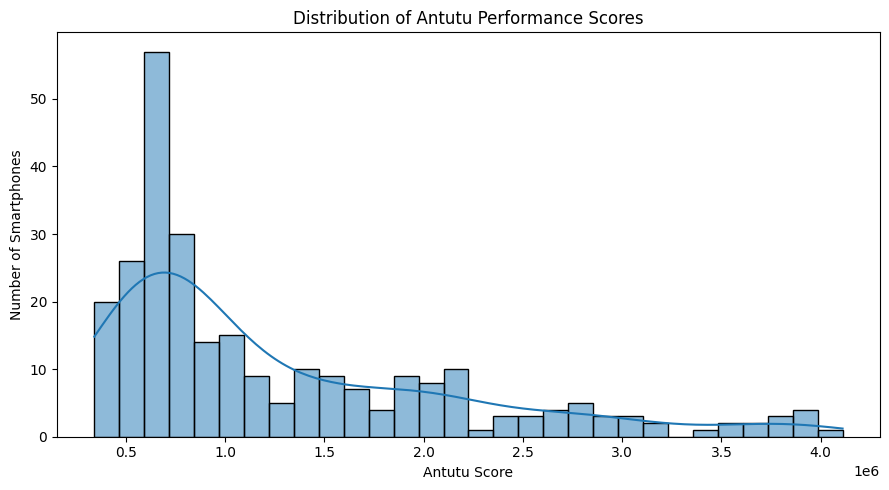

In [6]:
plt.figure(figsize=(9, 5))

sns.histplot(
    phones[TARGET],
    bins=30,
    kde=True
)

plt.title("Distribution of Antutu Performance Scores")
plt.xlabel("Antutu Score")
plt.ylabel("Number of Smartphones")

plt.tight_layout()
plt.show()

### 3. Defining Hardware Features

For Experiment A:

Hardware specifications predicting  Antutu performance without using other benchmarks

In [16]:
features = [
    "processor",
    "processor_type",
    "fab",
    "ram_type",
    "rom_type",
    "size",
    "thickness"
]

In [17]:
X = phones[features].copy()
y = phones["antutu"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (270, 7)
Target shape: (270,)


,processor,processor_type,fab,ram_type,rom_type,size,thickness
0,Dimensity 7300,Mediatek,4,LPDDR4X,UFS 2.2,6.67,8.2
1,Dimensity 7300,Mediatek,4,LPDDR4X,UFS 2.2,6.77,7.8
2,Dimensity 6300,Mediatek,6,LPDDR4X,UFS 2.2,6.70,8.2
3,1330,Exynos,5,LPDDR4X,UFS 2.2,6.70,7.5
4,6 Gen 3,Snapdragon,4,LPDDR5X,UFS 3.1,6.70,7.8


In [18]:
numeric_features = [
    "fab",
    "size",
    "thickness"
]

categorical_features = [
    "processor",
    "processor_type",
    "ram_type",
    "rom_type"
]

### 4. Preprocessing

In [19]:
numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

### 5. Cross Validation

In [20]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

### 6. Initial baseline

In [21]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median"))
    ]
)

dummy_results = cross_validate(
    dummy_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [22]:
dummy_mae = -dummy_results["test_mae"].mean()
dummy_rmse = -dummy_results["test_rmse"].mean()
dummy_r2 = dummy_results["test_r2"].mean()

print(f"Dummy MAE:  {dummy_mae:,.0f}")
print(f"Dummy RMSE: {dummy_rmse:,.0f}")
print(f"Dummy R²:   {dummy_r2:.3f}")


Dummy MAE:  653,657
Dummy RMSE: 982,746
Dummy R²:   -0.227


### 7. Ridge Regression

In [23]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0))
    ]
)

ridge_results = cross_validate(
    ridge_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [24]:
ridge_mae = -ridge_results["test_mae"].mean()
ridge_rmse = -ridge_results["test_rmse"].mean()
ridge_r2 = ridge_results["test_r2"].mean()
ridge_r2_std = ridge_results["test_r2"].std()

print(f"Ridge MAE:    {ridge_mae:,.0f}")
print(f"Ridge RMSE:   {ridge_rmse:,.0f}")
print(f"Ridge R²:     {ridge_r2:.3f}")
print(f"Ridge R² std: {ridge_r2_std:.3f}")

Ridge MAE:    240,423
Ridge RMSE:   331,687
Ridge R²:     0.858
Ridge R² std: 0.034


### 8. Random Forest

In [25]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [26]:
rf_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [27]:
rf_mae = -rf_results["test_mae"].mean()
rf_rmse = -rf_results["test_rmse"].mean()
rf_r2 = rf_results["test_r2"].mean()
rf_r2_std = rf_results["test_r2"].std()

print(f"Random Forest MAE:    {rf_mae:,.0f}")
print(f"Random Forest RMSE:   {rf_rmse:,.0f}")
print(f"Random Forest R²:     {rf_r2:.3f}")
print(f"Random Forest R² std: {rf_r2_std:.3f}")

Random Forest MAE:    167,784
Random Forest RMSE:   266,846
Random Forest R²:     0.904
Random Forest R² std: 0.042


### 9. Extra Trees

In [28]:
extra_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [29]:
extra_results = cross_validate(
    extra_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [30]:
extra_mae = -extra_results["test_mae"].mean()
extra_rmse = -extra_results["test_rmse"].mean()
extra_r2 = extra_results["test_r2"].mean()
extra_r2_std = extra_results["test_r2"].std()

print(f"Extra Trees MAE:    {extra_mae:,.0f}")
print(f"Extra Trees RMSE:   {extra_rmse:,.0f}")
print(f"Extra Trees R²:     {extra_r2:.3f}")
print(f"Extra Trees R² std: {extra_r2_std:.3f}")

Extra Trees MAE:    141,509
Extra Trees RMSE:   236,413
Extra Trees R²:     0.923
Extra Trees R² std: 0.039


### 10. Gradient Boosting

In [31]:
dense_categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [32]:
dense_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            dense_categorical_pipeline,
            categorical_features
        )
    ]
)

In [33]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=2,
                min_samples_leaf=3,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [34]:
gb_results = cross_validate(
    gb_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [35]:
gb_mae = -gb_results["test_mae"].mean()
gb_rmse = -gb_results["test_rmse"].mean()
gb_r2 = gb_results["test_r2"].mean()
gb_r2_std = gb_results["test_r2"].std()

print(f"Gradient Boosting MAE:    {gb_mae:,.0f}")
print(f"Gradient Boosting RMSE:   {gb_rmse:,.0f}")
print(f"Gradient Boosting R²:     {gb_r2:.3f}")
print(f"Gradient Boosting R² std: {gb_r2_std:.3f}")

Gradient Boosting MAE:    178,821
Gradient Boosting RMSE:   260,924
Gradient Boosting R²:     0.909
Gradient Boosting R² std: 0.034


### Experiment B: Adding Geekbench

If Geekbench performance is known, how much better Antutu Score can be predicted?

### 11. Adding Geekbench Features

In [36]:
features_benchmark = features + [
    "geekbench_single",
    "geekbench_multiple"
]

X_benchmark = phones[features_benchmark].copy()

In [38]:
numeric_features_benchmark = [
    "fab",
    "size",
    "thickness",
    "geekbench_single",
    "geekbench_multiple"
]

categorical_features_benchmark = [
    "processor",
    "processor_type",
    "ram_type",
    "rom_type"
]

### 12. New Preprocessing

In [39]:
numeric_pipeline_benchmark = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline_benchmark = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor_benchmark = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_benchmark,
            numeric_features_benchmark
        ),
        (
            "categorical",
            categorical_pipeline_benchmark,
            categorical_features_benchmark
        )
    ]
)

### 13. Extra Trees 

In [40]:
extra_benchmark_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_benchmark),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [41]:
extra_benchmark_results = cross_validate(
    extra_benchmark_pipeline,
    X_benchmark,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [42]:
extra_benchmark_mae = -extra_benchmark_results["test_mae"].mean()
extra_benchmark_rmse = -extra_benchmark_results["test_rmse"].mean()
extra_benchmark_r2 = extra_benchmark_results["test_r2"].mean()
extra_benchmark_r2_std = extra_benchmark_results["test_r2"].std()

print(f"Benchmark Extra Trees MAE:    {extra_benchmark_mae:,.0f}")
print(f"Benchmark Extra Trees RMSE:   {extra_benchmark_rmse:,.0f}")
print(f"Benchmark Extra Trees R²:     {extra_benchmark_r2:.3f}")
print(f"Benchmark Extra Trees R² std: {extra_benchmark_r2_std:.3f}")

Benchmark Extra Trees MAE:    104,545
Benchmark Extra Trees RMSE:   158,523
Benchmark Extra Trees R²:     0.966
Benchmark Extra Trees R² std: 0.014


### 14. Comparing A and B experiments

In [43]:
print("Hardware-only Extra Trees")
print(f"MAE:  {extra_mae:,.0f}")
print(f"RMSE: {extra_rmse:,.0f}")
print(f"R²:   {extra_r2:.3f}")

print("\nHardware + Geekbench Extra Trees")
print(f"MAE:  {extra_benchmark_mae:,.0f}")
print(f"RMSE: {extra_benchmark_rmse:,.0f}")
print(f"R²:   {extra_benchmark_r2:.3f}")

print("\nChange after adding Geekbench")
print(f"MAE improvement:  {extra_mae - extra_benchmark_mae:,.0f}")
print(f"RMSE improvement: {extra_rmse - extra_benchmark_rmse:,.0f}")
print(f"R² change:        {extra_benchmark_r2 - extra_r2:+.3f}")

Hardware-only Extra Trees
MAE:  141,509
RMSE: 236,413
R²:   0.923

Hardware + Geekbench Extra Trees
MAE:  104,545
RMSE: 158,523
R²:   0.966

Change after adding Geekbench
MAE improvement:  36,964
RMSE improvement: 77,890
R² change:        +0.043


### Experiment B — Benchmark-Assisted Performance Prediction

Adding Geekbench single-core and multi-core scores substantially improved Antutu prediction.

Extra Trees improved when Geekbench scores were added, while both MAE and RMSE decreased considerably.

This indicates that Geekbench contains additional performance information not fully captured by the selected hardware attributes. However, because Geekbench is itself a performance benchmark, this experiment is interpreted as benchmark-assisted prediction rather than purely hardware-based performance estimation.

### 15. Processor-grouped validation

In [48]:
groups = phones["processor"]


In [50]:
from sklearn.model_selection import GroupKFold

group_cv = GroupKFold(n_splits=5)

### 16. Hardware-only grouped evaluation

In [46]:
group_hw_results = cross_validate(
    extra_pipeline,
    X,
    y,
    cv=group_cv,
    groups=groups,
    scoring=scoring,
    n_jobs=-1
)

In [51]:
group_hw_mae = -group_hw_results["test_mae"].mean()
group_hw_rmse = -group_hw_results["test_rmse"].mean()
group_hw_r2 = group_hw_results["test_r2"].mean()
group_hw_r2_std = group_hw_results["test_r2"].std()

print(f"Grouped Hardware MAE:    {group_hw_mae:,.0f}")
print(f"Grouped Hardware RMSE:   {group_hw_rmse:,.0f}")
print(f"Grouped Hardware R²:     {group_hw_r2:.3f}")
print(f"Grouped Hardware R² std: {group_hw_r2_std:.3f}")

Grouped Hardware MAE:    267,044
Grouped Hardware RMSE:   383,414
Grouped Hardware R²:     0.791
Grouped Hardware R² std: 0.080


### 17. Compare normal CV vs processor-grouped CV

In [52]:
print("NORMAL CV — Hardware Only")
print(f"MAE:  {extra_mae:,.0f}")
print(f"RMSE: {extra_rmse:,.0f}")
print(f"R²:   {extra_r2:.3f}")

print("\nPROCESSOR-GROUPED CV — Hardware Only")
print(f"MAE:  {group_hw_mae:,.0f}")
print(f"RMSE: {group_hw_rmse:,.0f}")
print(f"R²:   {group_hw_r2:.3f}")

print("\nGeneralization gap")
print(f"R² change: {group_hw_r2 - extra_r2:+.3f}")

NORMAL CV — Hardware Only
MAE:  141,509
RMSE: 236,413
R²:   0.923

PROCESSOR-GROUPED CV — Hardware Only
MAE:  267,044
RMSE: 383,414
R²:   0.791

Generalization gap
R² change: -0.132


In [53]:
group_benchmark_results = cross_validate(
    extra_benchmark_pipeline,
    X_benchmark,
    y,
    cv=group_cv,
    groups=groups,
    scoring=scoring,
    n_jobs=-1
)

In [54]:
group_benchmark_mae = -group_benchmark_results["test_mae"].mean()
group_benchmark_rmse = -group_benchmark_results["test_rmse"].mean()
group_benchmark_r2 = group_benchmark_results["test_r2"].mean()
group_benchmark_r2_std = group_benchmark_results["test_r2"].std()

print(f"Grouped Benchmark MAE:    {group_benchmark_mae:,.0f}")
print(f"Grouped Benchmark RMSE:   {group_benchmark_rmse:,.0f}")
print(f"Grouped Benchmark R²:     {group_benchmark_r2:.3f}")
print(f"Grouped Benchmark R² std: {group_benchmark_r2_std:.3f}")

Grouped Benchmark MAE:    185,025
Grouped Benchmark RMSE:   273,645
Grouped Benchmark R²:     0.897
Grouped Benchmark R² std: 0.042


### 18. Final four-way comparison

In [55]:
results_comparison = pd.DataFrame({
    "Experiment": [
        "Hardware — Normal CV",
        "Hardware — Processor Grouped",
        "Hardware + Geekbench — Normal CV",
        "Hardware + Geekbench — Processor Grouped"
    ],
    "MAE": [
        extra_mae,
        group_hw_mae,
        extra_benchmark_mae,
        group_benchmark_mae
    ],
    "RMSE": [
        extra_rmse,
        group_hw_rmse,
        extra_benchmark_rmse,
        group_benchmark_rmse
    ],
    "R2": [
        extra_r2,
        group_hw_r2,
        extra_benchmark_r2,
        group_benchmark_r2
    ]
})

results_comparison.round({
    "MAE": 0,
    "RMSE": 0,
    "R2": 3
})

,Experiment,MAE,RMSE,R2
0,Hardware — Normal CV,141509.0,236413.0,0.923
1,Hardware — Processor Grouped,267044.0,383414.0,0.791
2,Hardware + Geekbench — Normal CV,104545.0,158523.0,0.966
3,Hardware + Geekbench — Processor Grouped,185025.0,273645.0,0.897


### Processor-Grouped Generalization

Standard cross-validation produced strong performance for both hardware-only and benchmark-assisted models. However, processor-grouped validation resulted in lower scores, showing that standard cross-validation benefits partly from having the same processor families represented across training and validation observations.

The hardware-only Extra Trees model's score decreased when evaluated on unseen processors, indicating that processor identity carries substantial predictive information.

Adding Geekbench scores improved generalization considerably.

Overall, the results show that hardware specifications can predict smartphone performance effectively, while related benchmark measurements provide additional transferable information when estimating performance for previously unseen processors.

### Experiment C: Prediciting Without Thickness & Screen Size

In [60]:
features_core = [
    "processor",
    "processor_type",
    "fab",
    "ram_type",
    "rom_type"
]

In [61]:
X_core = phones[features_core].copy()
y = phones["antutu"].copy()

In [62]:
numeric_features_core = [
    "fab"
]

categorical_features_core = [
    "processor",
    "processor_type",
    "ram_type",
    "rom_type"
]

In [63]:
numeric_pipeline_core = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline_core = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor_core = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_core,
            numeric_features_core
        ),
        (
            "categorical",
            categorical_pipeline_core,
            categorical_features_core
        )
    ]
)

In [64]:
extra_core_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_core),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [65]:
extra_core_results = cross_validate(
    extra_core_pipeline,
    X_core,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [66]:
extra_core_mae = -extra_core_results["test_mae"].mean()
extra_core_rmse = -extra_core_results["test_rmse"].mean()
extra_core_r2 = extra_core_results["test_r2"].mean()
extra_core_r2_std = extra_core_results["test_r2"].std()

print(f"Core Features Extra Trees MAE:    {extra_core_mae:,.0f}")
print(f"Core Features Extra Trees RMSE:   {extra_core_rmse:,.0f}")
print(f"Core Features Extra Trees R²:     {extra_core_r2:.3f}")
print(f"Core Features Extra Trees R² std: {extra_core_r2_std:.3f}")

Core Features Extra Trees MAE:    150,700
Core Features Extra Trees RMSE:   242,204
Core Features Extra Trees R²:     0.920
Core Features Extra Trees R² std: 0.039


Removing screen size and thickness had almost no impact on model performance. The Extra Trees model achieved almost similar R² using the larger hardware feature set, indicating that these physical dimensions contribute very little additional predictive information.

### Experiment D: Predicitng with Just Processors

In [67]:
features_processor = [
    "processor",
    "processor_type"
]

X_processor = phones[features_processor].copy()
y = phones["antutu"].copy()

In [68]:
categorical_features_processor = [
    "processor",
    "processor_type"
]

preprocessor_processor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_processor
        )
    ]
)

In [69]:
extra_processor_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_processor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [70]:
extra_processor_results = cross_validate(
    extra_processor_pipeline,
    X_processor,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
processor_mae = -extra_processor_results["test_mae"].mean()
processor_rmse = -extra_processor_results["test_rmse"].mean()
processor_r2 = extra_processor_results["test_r2"].mean()
processor_r2_std = extra_processor_results["test_r2"].std()

print(f"Processor-only Extra Trees MAE:    {processor_mae:,.0f}")
print(f"Processor-only Extra Trees RMSE:   {processor_rmse:,.0f}")
print(f"Processor-only Extra Trees R²:     {processor_r2:.3f}")
print(f"Processor-only Extra Trees R² std: {processor_r2_std:.3f}")

Processor-only Extra Trees MAE:    190,978
Processor-only Extra Trees RMSE:   334,825
Processor-only Extra Trees R²:     0.847
Processor-only Extra Trees R² std: 0.078


Using only processor and processor type reduced performance and increased fold-to-fold variability. This shows that processor identity is highly informative, but fabrication process and memory/storage technologies provide meaningful additional information for predicting Antutu performance.